# Exercise 01: Exploring and Analyzing Protein Structures in the PDB Database

## Learning Objectives

In this exercise, you will learn to:
- Query the PDB database programmatically
- Extract and analyze structural quality metrics
- **Critically evaluate** data quality and make informed decisions
- **Interpret** structural data in biological context
- Use a multiple sequence alignment to find conserved regions and relate them to structure

## Using AI Tools

You may use AI assistants (ChatGPT, Claude, etc.) for:
- Understanding syntax and library functions
- Debugging code errors
- Generating code snippets

However, **you must demonstrate**:
- Your own biological reasoning and interpretation
- Justification for decisions (not just "AI said so")
- Critical evaluation of results

**The exercise assesses your understanding and judgment, not code generation.**

**Exercise 01 is two notebooks:**

| Notebook | What it is |
|---|---|
| **`ex01_guide.ipynb`** (this one) | A fully worked walkthrough on one protein, 1FSZ. Every cell is filled in and explained. Nothing here is graded — read it, run it, and use it as your reference. |
| **`ex01_workbook.ipynb`** | The graded notebook. Open it once you have finished here. |

## Introduction and Basic Skills

We'll start by learning how to query PDB and extract structural information, using one
real protein — FtsZ, PDB entry **1FSZ** — end to end.

In [1]:
# Check if running on Google Colab
try:
    from google.colab import drive
    is_google_colab = True
except ImportError:
    is_google_colab = False

# If on Google Colab, install the package
if is_google_colab:
    %pip install numpy==2.1.3 scipy==1.16.3 pandas==2.2.3 biopandas==0.4.1 pypdb==2.4 tqdm==4.67.3 py3dmol==2.4.0

# NOTE: Ignore specific warning message from ipykernel=5.5.6
import warnings
import os


In [2]:
# Import libraries
import math
import requests
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pypdb
from biopandas.pdb import PandasPdb
import py3Dmol
from tqdm import tqdm


# Suppress all warnings at the Python level
warnings.filterwarnings('ignore')

# Also set environment variable to suppress warnings
os.environ['PYTHONWARNINGS'] = 'ignore'

# pandas draws through matplotlib by default -- df.plot() gives us a real Axes back,
# which keeps most plots in this notebook to two or three lines.
print("All libraries loaded successfully")

All libraries loaded successfully


/home/yerko/Development/structural-bioinformatics-lectures/exercises/.venv/lib/python3.13/site-packages/biopandas/pdb/pandas_pdb.py:27: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  pd_version = LooseVersion(pd.__version__)


### Meet FtsZ, and our anchor structure: 1FSZ

**FtsZ** is essential for bacterial (and archaeal) cell division: it self-assembles into
a contractile ring, the Z-ring, at the future division site and constricts to split the
cell in two. It is a structural and mechanistic homolog of eukaryotic **tubulin** — both
are GTPases that polymerize into dynamic filaments — which makes FtsZ both a textbook
case of convergent-yet-homologous cytoskeletal machinery and an attractive antibacterial
drug target (block the Z-ring, block division, without touching human tubulin directly).

FtsZ is not unique to *E. coli* — it is one of the most broadly conserved cell-division
proteins across the prokaryotic tree of life, found in nearly all bacteria **and** in many
archaea. For this whole walkthrough we anchor on one specific, well-characterized
structure: **1FSZ**, FtsZ from the archaeon *Methanocaldococcus jannaschii*.

Why this one, specifically:
- At 372 residues in the crystallized construct, it is large enough to show **two
  distinct domains** clearly: an N-terminal GTPase domain (the tubulin-homolog catalytic
  core, roughly residues 23-190) and a separate C-terminal domain (roughly 190-356) — a
  good structure to practice domain-level thinking on.
- It has its own **bound GDP** resolved in the crystal (not a crystallization
  artifact) — FtsZ, like tubulin, is a GTPase, and this is its real nucleotide.
- The crystal only ever resolved residues 23-356 — **38 residues at the very ends**
  (22 at the N-terminus, 16 at the C-terminus) were never modeled at all, and there are
  **no internal gaps** in the modeled range. You'll only spot the missing ends by noticing
  that the modeled range (23-356, 334 residues) is shorter than the full 372-residue
  construct — keep that number in mind for the B-factor section below.

Everything below — the database query, the quality classification, the visualization,
the conservation analysis — is built starting **from 1FSZ itself**, not from a separate,
disconnected search.

### The PDB, and why programmatic access matters

The RCSB PDB (Research Collaboratory for Structural Bioinformatics Protein Data Bank) is
the central open-access repository for 3D structures of biological macromolecules —
currently over 200,000 entries. You can browse and search it by hand at
[rcsb.org](https://www.rcsb.org/), and that's a fine way to look at *one* structure.

It stops being a fine way to work the moment you need to compare, filter, or classify
**many** structures at once — you can't click through 250 entries one at a time and keep
the comparison consistent. That's what a **programmatic API** is for: the PDB Search API
lets you send a single JSON query over HTTP and get every matching structure back as
structured JSON, ready to filter, sort, and turn into a table. The pattern is always the
same — **submit a query → get JSON back → parse it in code** — and you'll see this exact
pattern again later in this notebook for a completely different database (a sequence
alignment service), because it's the general shape of "talking to a big database," not a
one-off trick for the PDB specifically.

The API is documented at the [PDB Search API documentation](https://search.rcsb.org/index.html#search-api)
(with [worked examples](https://search.rcsb.org/index.html#examples)). We'll query it
directly with `requests`, and also use `pypdb`, a thin Python wrapper around the same API,
for some lookups. Later we'll use **BioPandas** to load an individual structure's atomic
coordinates into a pandas DataFrame for analysis.

### 1. Starting from 1FSZ: fetch its sequence, then search for all the FtsZ structures

Rather than searching with an arbitrary keyword or an off-species identifier, we start
from **1FSZ's own sequence** and ask the PDB: "what else in here looks like this?" That
is both a literal, checkable way to "search for all the FtsZ" and a query that is
**generic** — the exact same two cells below work for any structure, which is exactly
what you'll reuse on your own protein in the workbook.

In [3]:
# Fetch 1FSZ's own sequence directly from RCSB (FASTA format)
fasta_response = requests.get("https://www.rcsb.org/fasta/entry/1FSZ")
fasta_text = fasta_response.text

# A FASTA file is one header line ('>...') followed by the sequence, possibly wrapped
# over several lines -- join everything after the header into one sequence string.
fasta_lines = fasta_text.strip().splitlines()
anchor_header = fasta_lines[0]
anchor_sequence = "".join(fasta_lines[1:])

print(anchor_header)
print(f"1FSZ sequence length: {len(anchor_sequence)} residues")
print(anchor_sequence)


>1FSZ_1|Chain A|FTSZ|Methanocaldococcus jannaschii (2190)
1FSZ sequence length: 372 residues
MKFLKNVLEEGSKLEEFNELELSPEDKELLEYLQQTKAKITVVGCGGAGNNTITRLKMEGIEGAKTVAINTDAQQLIRTKADKKILIGKKLTRGLGAGGNPKIGEEAAKESAEEIKAAIQDSDMVFITCGLGGGTGTGSAPVVAEISKKIGALTVAVVTLPFVMEGKVRMKNAMEGLERLKQHTDTLVVIPNEKLFEIVPNMPLKLAFKVADEVLINAVKGLVELITKDGLINVDFADVKAVMNNGGLAMIGIGESDSEKRAKEAVSMALNSPLLDVDIDGATGALIHVMGPEDLTLEEAREVVATVSSRLDPNATIIWGATIDENLENTVRVLLVITGVQSRIEFTDTGLKRKKLELTGIPKIGSHHHHHH


In [4]:
# Build a sequence search: "find PDB entries whose sequence resembles 1FSZ's"
search_dict = {
    "query": {
        "type": "terminal",
        "service": "sequence",
        "parameters": {
            "evalue_cutoff": 1,
            "identity_cutoff": 0.3,  # at least 30% sequence identity to 1FSZ
            "target": "pdb_protein_sequence",
            "value": anchor_sequence,
        },
    },
    "return_type": "entry",
    "request_options": {
        "paginate": {"start": 0, "rows": 100},
        "sort": [{"sort_by": "score", "direction": "desc"}],
    },
}

# Send request to PDB API
response = requests.post(
    "https://search.rcsb.org/rcsbsearch/v2/query",
    json=search_dict,
)
data = response.json()

print(f"Found {data['total_count']} structures related to 1FSZ")
print(f"Retrieved {len(data['result_set'])} in this query")


Found 252 structures related to 1FSZ
Retrieved 100 in this query


In [5]:
# Extract PDB IDs from results -- 1FSZ itself should be the top hit (score 1.0),
# since it is a perfect match to its own sequence.
pdb_ids = [entry["identifier"] for entry in data["result_set"]]
print(f"Top 10 PDB IDs by similarity to 1FSZ: {pdb_ids[:10]}")
print(f"Is 1FSZ itself in the list, and is it first? {pdb_ids[0] == '1FSZ'}")


Top 10 PDB IDs by similarity to 1FSZ: ['1FSZ', '1W58', '1W59', '1W5A', '1W5B', '2VAP', '1W5E', '9V7V', '2RHH', '2RHJ']
Is 1FSZ itself in the list, and is it first? True


### 2. Extracting Structural Information

For each structure, we can extract quality metrics like resolution, R-factors,
experimental method, etc. We are doing the same as the previous step but now via the
`pypdb` library to get detailed information about each PDB structure.

In [6]:
# Example: Get detailed info for 1FSZ itself
example_pdb = "1FSZ"
info = pypdb.get_info(example_pdb)

print(f"Structure: {example_pdb}")
print(f"Title: {info['struct']['title'][:80]}...")
print(f"Method: {info['exptl'][0]['method']}")
print(f"Year: {info['rcsb_accession_info']['deposit_date'][:4]}")

# Resolution (only for X-ray/Cryo-EM)
if "refine" in info and info["refine"]:
    resolution = info["refine"][0].get("ls_d_res_high")
    if resolution:
        print(f"Resolution: {resolution} Å")


Structure: 1FSZ
Title: CRYSTAL STRUCTURE OF THE CELL-DIVISION PROTEIN FTSZ AT 2.8A RESOLUTION...
Method: X-RAY DIFFRACTION
Year: 1997
Resolution: 2.8 Å


### 3. Batch Processing with Error Handling

When processing many structures, we need robust code that handles missing data —
not every method reports the same fields (NMR structures have no resolution, for
instance).

In [7]:
def extract_structure_info(pdb_id):
    """Extract key information from a PDB entry."""
    try:
        info = pypdb.get_info(pdb_id)

        # Basic info (always present)
        result = {
            "pdb_id": pdb_id,
            "method": info["exptl"][0]["method"],
            "year": info["rcsb_accession_info"]["deposit_date"][:4],
        }

        # Resolution (may be missing for NMR)
        if "refine" in info and info["refine"]:
            result["resolution"] = info["refine"][0].get("ls_d_res_high")
            result["r_work"] = info["refine"][0].get("ls_R_factor_R_work")
            result["r_free"] = info["refine"][0].get("ls_R_factor_R_free")
        else:
            result["resolution"] = None
            result["r_work"] = None
            result["r_free"] = None

        return result

    except Exception as e:
        print(f"Error processing {pdb_id}: {e}")
        return None


# Process the first 20 structures from our 1FSZ-rooted search
structures_data = []
for pdb_id in tqdm(pdb_ids[:20], desc="Processing structures"):
    info_row = extract_structure_info(pdb_id)
    if info_row:
        structures_data.append(info_row)

# Create DataFrame
df = pd.DataFrame(structures_data)
print(f"\n✓ Successfully processed {len(df)} structures")
df.head()


Processing structures:   0%|          | 0/20 [00:00<?, ?it/s]

Processing structures:   5%|▌         | 1/20 [00:00<00:06,  3.06it/s]

Processing structures:  10%|█         | 2/20 [00:00<00:05,  3.05it/s]

Processing structures:  15%|█▌        | 3/20 [00:00<00:05,  3.07it/s]

Processing structures:  20%|██        | 4/20 [00:01<00:05,  3.08it/s]

...

Processing structures:  95%|█████████▌| 19/20 [00:06<00:00,  2.99it/s]

Processing structures: 100%|██████████| 20/20 [00:06<00:00,  3.02it/s]

Processing structures: 100%|██████████| 20/20 [00:06<00:00,  3.02it/s]


✓ Successfully processed 20 structures


,pdb_id,method,year,resolution,r_work,r_free
0,1FSZ,X-RAY DIFFRACTION,1997,2.8,0.199,0.282
1,1W58,X-RAY DIFFRACTION,2004,2.5,0.221,0.253
2,1W59,X-RAY DIFFRACTION,2004,2.7,0.216,0.296
3,1W5A,X-RAY DIFFRACTION,2004,2.4,0.218,0.264
4,1W5B,X-RAY DIFFRACTION,2004,2.2,0.209,0.259


### 4. Basic Analysis and Visualization

In [8]:
# Summary statistics
print("=== Dataset Summary ===")
print(f"Total structures: {len(df)}")
print(f"\nBy experimental method:")
print(df["method"].value_counts())

# Resolution statistics (X-ray only)
xray_df = df[df["method"] == "X-RAY DIFFRACTION"]
resolutions = xray_df["resolution"].dropna()
if len(resolutions) > 0:
    print(
        f"\nX-ray resolution range: {resolutions.min():.2f} - {resolutions.max():.2f} Å"
    )
    print(f"Mean resolution: {resolutions.mean():.2f} Å")


=== Dataset Summary ===
Total structures: 20

By experimental method:
method
X-RAY DIFFRACTION      19
ELECTRON MICROSCOPY     1
Name: count, dtype: int64

X-ray resolution range: 1.43 - 3.19 Å
Mean resolution: 2.30 Å


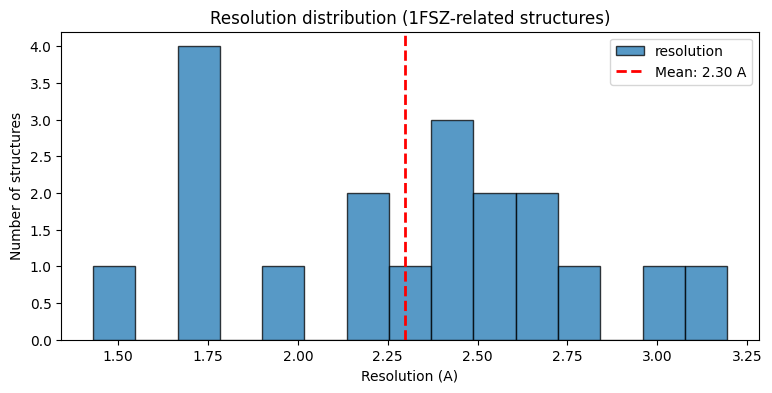

n = 19   mean 2.30 A   best 1.43 A   worst 3.19 A


In [9]:
# Resolution distribution, straight off the DataFrame.
xray = df.loc[df["method"] == "X-RAY DIFFRACTION", "resolution"].dropna()

if len(xray):
    ax = xray.plot.hist(
        bins=15, edgecolor="black", alpha=0.75, figsize=(9, 4),
        title="Resolution distribution (1FSZ-related structures)",
    )
    ax.axvline(xray.mean(), color="red", ls="--", lw=2,
               label=f"Mean: {xray.mean():.2f} A")
    ax.set_xlabel("Resolution (A)")
    ax.set_ylabel("Number of structures")
    ax.legend()
    plt.show()

    print(f"n = {len(xray)}   mean {xray.mean():.2f} A   "
          f"best {xray.min():.2f} A   worst {xray.max():.2f} A")
else:
    print("No X-ray structures with a resolution in this sample.")

### 5. Quick Structure Visualization with py3Dmol

In [10]:
# Visualize the best-resolution X-ray structure in our sample
best_structure = (
    df[df["method"] == "X-RAY DIFFRACTION"].nsmallest(1, "resolution").iloc[0]
)
print(
    f"Visualizing: {best_structure['pdb_id']} (Resolution: {best_structure['resolution']:.2f} Å)"
)

view = py3Dmol.view(query=f"pdb:{best_structure['pdb_id']}", width=800, height=500)
view.setStyle({"cartoon": {"color": "spectrum"}})
view.zoomTo()
view.show()


Visualizing: 4M8I (Resolution: 1.43 Å)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### 6. Structure Analysis with BioPandas

Now let's zoom in on our anchor structure, 1FSZ itself, for a deeper analysis. We'll use
BioPandas to load its atomic coordinates into a pandas DataFrame.

In [11]:
# Fetch 1FSZ using BioPandas
pdb_id = "1FSZ"
print(f"Analyzing structure: {pdb_id}")

# Fetch PDB file using BioPandas
ppdb = PandasPdb().fetch_pdb(pdb_id)

# Get the ATOM records (protein atoms)
atoms_df = ppdb.df["ATOM"]

print(f"Total atoms in structure: {len(atoms_df)}")
print(f"Unique residues: {atoms_df['residue_number'].nunique()}")

# Display first few rows to understand the data structure
print("\nFirst few rows of atomic data:")
atoms_df.head()


Analyzing structure: 1FSZ


Total atoms in structure: 2479
Unique residues: 334

First few rows of atomic data:


,record_name,atom_number,blank_1,atom_name,alt_loc,residue_name,blank_2,chain_id,residue_number,insertion,...,x_coord,y_coord,z_coord,occupancy,b_factor,blank_4,segment_id,element_symbol,charge,line_idx
0,ATOM,1,,N,,SER,,A,23,,...,18.623,-11.552,-5.579,1.0,74.80,,,N,NaN,497
1,ATOM,2,,CA,,SER,,A,23,,...,17.707,-10.891,-4.602,1.0,70.57,,,C,NaN,498
2,ATOM,3,,C,,SER,,A,23,,...,17.275,-9.526,-5.088,1.0,70.22,,,C,NaN,499
3,ATOM,4,,O,,SER,,A,23,,...,18.004,-8.861,-5.812,1.0,71.08,,,O,NaN,500
4,ATOM,5,,CB,,SER,,A,23,,...,18.399,-10.704,-3.259,1.0,71.24,,,C,NaN,501


### What else is in the crystal? Cataloguing the heteroatoms

A PDB entry is not just a protein. Everything that was in the crystal and could be
modelled into the density is in the file, recorded as `HETATM` rather than `ATOM`:
substrates, cofactors, metal ions, and — very often — molecules that have nothing to do
with the biology at all.

**This distinction is one of the most consequential things to get right about a
structure**, and it is easy to get wrong. Buffer components (HEPES, acetate), solvents
(glycerol, ethanol), cryoprotectants and crystallisation additives all appear in exactly
the same way as a real substrate. Nothing in the file marks which is which. A study that
docks against a cryoprotectant, or "discovers" a binding site that is really a buffer
molecule wedged in a surface cleft, is a study built on a misread `HETATM` record.

So before doing anything else with a structure, list what is actually in it.

In [12]:
# Every non-protein species in 1FSZ, with how many atoms each contributes.
hetatms = ppdb.df["HETATM"]

inventory = (
    hetatms.groupby("residue_name")
    .agg(atoms=("atom_number", "size"), copies=("residue_number", "nunique"))
    .sort_values("atoms", ascending=False)
)
print(f"Heteroatom species in {pdb_id}:\n")
print(inventory.to_string())

print("\nWater atoms:", len(hetatms[hetatms["residue_name"] == "HOH"]))
print("Non-water heteroatoms:", len(hetatms[hetatms["residue_name"] != "HOH"]))

Heteroatom species in 1FSZ:

              atoms  copies
residue_name               
HOH             116     116
GDP              28       1

Water atoms: 116
Non-water heteroatoms: 28


**1FSZ is a clean case.** Two species: water, and **GDP** — a real nucleotide, the thing
FtsZ actually binds and hydrolyses. Nothing else was modelled. If every structure looked
like this the distinction would not be worth teaching.

They do not. For contrast, **2IEN** — an HIV-1 protease structure you will meet again in
ex04 — contains **six** heteroatom species:

| Code | What it is | Real, or artifact? |
|---|---|---|
| `017` | darunavir, the inhibitor the structure was solved to study | **the biological ligand** |
| `GOL` | glycerol | cryoprotectant |
| `ACY` | acetic acid | buffer component |
| `NA`, `CL` | sodium, chloride | ions from the crystallisation buffer |
| `HOH` | water | solvent |

Five of the six are experimental scaffolding. Only one is the molecule the paper is about.
A pipeline that simply grabs "the largest non-water heteroatom" would get this right by
luck here, and would get it wrong the moment a cryoprotectant happens to be bigger.

**How to tell them apart.** No single rule settles it, so use several:

- **Look it up.** The RCSB entry page names the ligands and the paper says what was
  studied. This is the reliable route; the rest are heuristics.
- **Where is it?** A ligand buried in a well-formed pocket, making several specific
  contacts, is more likely real than one perched in a shallow surface groove.
- **Do you recognise it as a lab reagent?** Glycerol, ethylene glycol, HEPES, MES, PEG
  fragments, sulfate, acetate, DMSO — these are almost always from the experiment.
- **Is it in related structures?** A cofactor recurs across a protein family; a
  cryoprotectant is an accident of one crystallisation.
- **Occupancy and B-factors** — a poorly-ordered, partially-occupied molecule is more
  often an artifact than a tightly-bound substrate.

In [13]:
# Where does 1FSZ's GDP actually sit? Residues within 4 A of it.
from scipy.spatial import cKDTree

gdp = hetatms[hetatms["residue_name"] == "GDP"][["x_coord", "y_coord", "z_coord"]].values
prot = atoms_df[["x_coord", "y_coord", "z_coord"]].values

tree = cKDTree(prot)
near = sorted({i for hit in tree.query_ball_point(gdp, r=4.0) for i in hit})
contacts = (
    atoms_df.iloc[near][["residue_number", "residue_name"]]
    .drop_duplicates()
    .sort_values("residue_number")
)
print(f"Residues within 4 A of GDP: {len(contacts)}\n")
print(", ".join(f"{r.residue_name}{r.residue_number}" for r in contacts.itertuples()))

Residues within 4 A of GDP: 17

GLY46, GLY47, ALA48, ASN51, GLY130, LEU131, GLY133, GLY134, THR135, GLY136, PRO161, GLU165, ARG169, PHE208, ALA211, ASP212, LEU215


That contact list is the **binding site**, derived from geometry rather than assumed. Keep
it: a real ligand sits in a pocket lined by many residues making specific contacts, and
you can now say concretely which ones. It is also the list to compare against the
conserved positions you compute further down — if evolution has conserved the residues
that touch the nucleotide, that is a strong, checkable signal that the site matters.

### 7. B-factor Analysis

B-factors (temperature factors) indicate atomic mobility and flexibility in protein
structures. Let's analyze B-factor patterns to understand protein dynamics and identify
flexible regions.

In [14]:
# Get CA atoms for B-factor analysis
ca_atoms = atoms_df[atoms_df["atom_name"] == "CA"].copy()

print(f"Analyzing B-factors for {len(ca_atoms)} residues")


Analyzing B-factors for 334 residues


**How you'd reason about this before plotting (a worked example of predict-first):**

1FSZ has an N-terminal GTPase domain (roughly residues 23-190, the tubulin-homolog
catalytic core) and a C-terminal domain (roughly residues 190-356). Before looking at any
numbers, the biologically motivated prediction is: the catalytic GTPase domain does the
core, conserved, GTP-binding/hydrolysis job — that kind of functional core is usually
**more rigid** (lower B-factor) than a more peripheral domain, which has more freedom to
move without breaking the protein's central function.

This is exactly the kind of prediction you should write down **before** running the plot
below, on your own protein, in the workbook — being wrong is fine, the point is
to have a falsifiable guess on record before you see the answer.

Residue range: 23 to 356
Present residues: 334
Missing residues: 0

B-factor statistics:
count    334.00
mean      50.65
std       18.78
min       18.96
25%       35.95
50%       45.53
75%       63.02
max       99.80


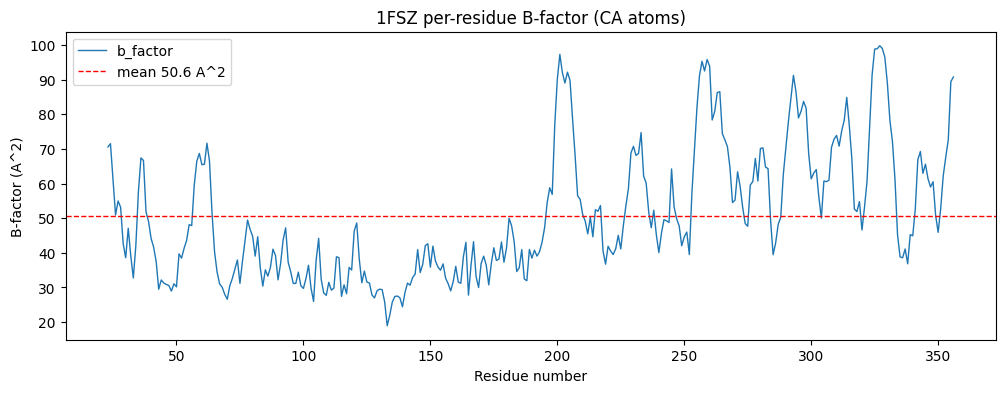

In [15]:
# B-factor along the chain, with real gaps where the crystal resolved nothing.
#
# Rather than building a dict and a list of None by hand, put the data in a Series
# indexed by residue number and `reindex` onto the full range: pandas inserts NaN for
# the missing residues, and matplotlib draws a gap wherever it finds one.
bfactors = (
    ca_atoms.set_index("residue_number")["b_factor"]
    .reindex(range(ca_atoms["residue_number"].min(), ca_atoms["residue_number"].max() + 1))
)
bfactors.index.name = "Residue number"

print(f"Residue range: {bfactors.index.min()} to {bfactors.index.max()}")
print(f"Present residues: {bfactors.notna().sum()}")
print(f"Missing residues: {bfactors.isna().sum()}")
print(f"\nB-factor statistics:\n{bfactors.describe().round(2).to_string()}")

ax = bfactors.plot(figsize=(12, 4), lw=1,
                   title="1FSZ per-residue B-factor (CA atoms)")
ax.axhline(bfactors.mean(), color="red", ls="--", lw=1,
           label=f"mean {bfactors.mean():.1f} A^2")
ax.set_ylabel("B-factor (A^2)")
ax.legend()
plt.show()

**What this confirms:** the GTPase domain (~38 Ų mean) is indeed noticeably more
rigid than the C-terminal domain (~63 Ų mean) — the prediction above holds. Note also
that this plot has **zero internal gaps**: the 38 unresolved residues (22 N-terminal, 16
C-terminal) don't show up as a break *inside* this range, because they're entirely outside
it (residue numbers 1-22 and 357-372 simply never appear in `ca_atoms` at all). You only
notice they're missing by checking the modeled count (334) against the full construct
(372) — a gap worth remembering when we come to structure prediction.

---

## Final code: classifying structural quality across the 1FSZ family

A common real task: given many structures of the same protein, which one should you
use? Below is a small, **correct, final** function for that — no bugs to find, this is
what a working version of "find the best structure" looks like — followed by a worked
walkthrough applying it to the real 1FSZ-rooted dataset from above.

This is not a fill-in-the-blank exercise: everything below is filled in and explained.

In [16]:
def find_best_structure(uniprot_id_or_sequence, use_sequence=True):
    """Find the highest-resolution experimental structure for a protein.

    Works generically for any UniProt ID (full-text search) or sequence
    (sequence search, as used throughout this notebook for 1FSZ).
    Returns None, with an explanatory message, if nothing usable is found --
    it does not crash on missing data, and it does not silently return a
    wrong answer.
    """
    if use_sequence:
        search_dict = {
            "query": {
                "type": "terminal",
                "service": "sequence",
                "parameters": {
                    "evalue_cutoff": 1,
                    "identity_cutoff": 0.3,
                    "target": "pdb_protein_sequence",
                    "value": uniprot_id_or_sequence,
                },
            },
            "return_type": "entry",
            "request_options": {"paginate": {"start": 0, "rows": 100}},
        }
    else:
        search_dict = {
            "query": {
                "type": "terminal",
                "service": "full_text",
                "parameters": {"value": uniprot_id_or_sequence},
            },
            "return_type": "entry",
            "request_options": {"paginate": {"start": 0, "rows": 100}},
        }

    response = requests.post(
        "https://search.rcsb.org/rcsbsearch/v2/query", json=search_dict
    )
    response.raise_for_status()
    data = response.json()

    candidate_ids = [entry["identifier"] for entry in data.get("result_set", [])]
    if not candidate_ids:
        print("No candidate structures found for this query.")
        return None

    best_pdb = None
    best_resolution = None  # lower Å is better -- track the minimum, not the maximum

    for candidate_id in candidate_ids:
        try:
            info = pypdb.get_info(candidate_id)
        except Exception as e:
            print(f"Skipping {candidate_id}: could not fetch info ({e})")
            continue

        # Not every method (e.g. NMR) reports a resolution -- skip those safely
        # instead of crashing on a missing key.
        if "refine" not in info or not info["refine"]:
            continue
        resolution = info["refine"][0].get("ls_d_res_high")
        if resolution is None:
            continue

        if best_resolution is None or resolution < best_resolution:
            best_resolution = resolution
            best_pdb = candidate_id

    if best_pdb is None:
        print("No candidate structure reported a usable resolution value.")
        return None

    return best_pdb, best_resolution


**Why this version works, compared to a naive first attempt:**
- It compares resolution values looking for the **minimum** — in Å, *lower* is better
  (a common first mistake is to search for the maximum instead).
- It only paginates through the JSON response it actually got (`request_options`), rather
  than assuming the first page contains everything.
- It skips entries missing a `refine`/resolution field (NMR structures, for instance)
  instead of raising a `KeyError` and crashing the whole batch.
- It wraps the per-structure `pypdb.get_info` call in its own `try/except`, so one bad
  entry doesn't stop the rest of the batch from being processed — the same pattern as
  `extract_structure_info` above.
- It supports both a UniProt-ID text search and a sequence search, so it is reusable
  as-is on your own protein in the workbook, whichever kind of query you have.

In [17]:
# Apply it to our real 1FSZ-rooted dataset
best_pdb, best_res = find_best_structure(anchor_sequence, use_sequence=True)
print(f"Best-resolution structure in the 1FSZ family: {best_pdb} ({best_res:.2f} Å)")


Best-resolution structure in the 1FSZ family: 6RVQ (1.14 Å)


### A structural-quality classification, built on real data

Instead of a made-up table, let's classify the real structures already sitting in `df`
(the 20 structures batch-processed earlier) using simple, defensible resolution tiers.

In [18]:
def classify_quality(row):
    if row["method"] != "X-RAY DIFFRACTION" or pd.isna(row["resolution"]):
        return "no resolution metric (use ensemble spread / local confidence instead)"
    if row["resolution"] < 2.0:
        return "excellent (< 2.0 Å) -- good for drug design / precise side-chain geometry"
    if row["resolution"] < 3.0:
        return "good (2.0-3.0 Å) -- reliable backbone, side-chain placement less certain"
    return "moderate (> 3.0 Å) -- backbone topology only, don't trust fine detail"


df["quality_tier"] = df.apply(classify_quality, axis=1)
df[["pdb_id", "method", "resolution", "r_free", "quality_tier"]].sort_values(
    "resolution", na_position="last"
)


,pdb_id,method,resolution,r_free,quality_tier
16,4M8I,X-RAY DIFFRACTION,1.430,0.20616,excellent (< 2.0 Å) -- good for drug design / ...
5,2VAP,X-RAY DIFFRACTION,1.700,0.20900,excellent (< 2.0 Å) -- good for drug design / ...
13,2VXY,X-RAY DIFFRACTION,1.700,0.21800,excellent (< 2.0 Å) -- good for drug design / ...
19,3VOA,X-RAY DIFFRACTION,1.730,0.22990,excellent (< 2.0 Å) -- good for drug design / ...
9,2RHJ,X-RAY DIFFRACTION,1.761,0.20800,excellent (< 2.0 Å) -- good for drug design / ...
8,2RHH,X-RAY DIFFRACTION,2.001,0.25700,"good (2.0-3.0 Å) -- reliable backbone, side-ch..."
15,3WGJ,X-RAY DIFFRACTION,2.179,0.23520,"good (2.0-3.0 Å) -- reliable backbone, side-ch..."
4,1W5B,X-RAY DIFFRACTION,2.200,0.25900,"good (2.0-3.0 Å) -- reliable backbone, side-ch..."
17,3VO8,X-RAY DIFFRACTION,2.255,0.23700,"good (2.0-3.0 Å) -- reliable backbone, side-ch..."
3,1W5A,X-RAY DIFFRACTION,2.400,0.26400,"good (2.0-3.0 Å) -- reliable backbone, side-ch..."


### Worked critical evaluation: which structure for which purpose?

**Scenario:** you're planning a drug-design project on the FtsZ family, and separately
you want to study its flexibility. Which structure(s) from the table above would you
pick for each, and why?

**A worked answer (a model of the reasoning, not a template to copy verbatim for your own
protein):**
- **For drug design**, pick the structure `find_best_structure` returned above
  (`best_pdb`, at `best_res` Å) — the tightest resolution means the most precise
  side-chain and pocket geometry, which matters directly for docking or structure-based
  design. R-free (not just resolution) is worth checking too: a low resolution number
  with a high R-free means the model doesn't actually explain the diffraction data well,
  despite looking sharp on paper.
- **For studying flexibility**, resolution is a much weaker signal than the B-factor
  section above already showed — even a single well-resolved structure like 1FSZ itself
  gives you a real per-residue flexibility profile via its B-factors, and cross-checking
  against **several** structures of the same protein (do they agree on which regions are
  most mobile?) is more informative than picking the "best" single one by resolution
  alone.
- **The general lesson:** "best resolution" and "best structure for this specific
  question" are not always the same structure — the quality tiers above are a starting
  filter, not a final verdict, and the same limitations-vs-purpose reasoning applies
  whatever protein you're working with.

---

## 8. Multiple sequence alignment: where is FtsZ conserved?

So far we've asked "how good is this structure?" Now let's ask a different question:
"which *parts* of the structure does evolution care most about?" A **multiple sequence
alignment (MSA)** across several FtsZ relatives lets us find columns that stayed
identical across large evolutionary distances — a strong signal that a residue matters
functionally, independent of any single structure's quality.

This reuses the exact same idea as the PDB Search API above — **submit a query, poll or
paginate, parse the JSON/text that comes back** — just aimed at a different database: the
EBI's **Job Dispatcher**, a REST API in front of bioinformatics tools including Clustal
Omega (for alignment). We already have the raw material: `pdb_ids`, the full list of
FtsZ-family hits from the sequence search at the top of this notebook.

**Choosing which sequences to align (a rule that has to work for any protein, not just
1FSZ):** aligning all ~250 hits would be slow to run and hard to read; aligning too few
makes "conserved" nearly meaningless (with only 2-3 sequences, almost everything looks
conserved by chance). We use a simple, generic rule: take up to **10** sequences, spread
evenly across the *ranked* hit list (from the closest match to the more distant ones,
not just the top 10 nearly-identical entries) so the alignment spans a real range of
evolutionary distance. If fewer than 3 hits exist at all (possible for an obscure
protein in the workbook), we skip the MSA rather than run a meaningless
alignment on 1-2 sequences.

In [19]:
# Select up to 10 sequences, evenly spread across the ranked hit list (not just the
# top 10 nearest matches), so the alignment spans real evolutionary distance.
MAX_SEQUENCES = 10
MIN_SEQUENCES = 3

if len(pdb_ids) < MIN_SEQUENCES:
    print(
        f"Only {len(pdb_ids)} related structure(s) found -- too few for a meaningful "
        f"alignment (need at least {MIN_SEQUENCES}). Skipping the MSA step."
    )
    msa_subset_ids = []
else:
    n_available = len(pdb_ids)
    n_selected = min(MAX_SEQUENCES, n_available)
    # Evenly spaced indices from 0 to n_available-1, always including the first hit
    # (1FSZ itself) and spreading the rest across the full ranked list.
    indices = sorted({round(i * (n_available - 1) / (n_selected - 1)) for i in range(n_selected)})
    msa_subset_ids = [pdb_ids[i] for i in indices]

print(f"Selected {len(msa_subset_ids)} sequences for the alignment: {msa_subset_ids}")


Selected 10 sequences for the alignment: ['1FSZ', '2RHO', '3WGN', '6RVM', '7OHN', '5H5H', '14UJ', '14UU', '14VF', '14VQ']


In [20]:
# Fetch each selected structure's sequence as FASTA and combine into one multi-FASTA
multi_fasta_parts = []
for entry_id in msa_subset_ids:
    r = requests.get(f"https://www.rcsb.org/fasta/entry/{entry_id}")
    multi_fasta_parts.append(r.text.strip())

multi_fasta_text = "\n".join(multi_fasta_parts) + "\n"
print(multi_fasta_text[:300], "...")


>1FSZ_1|Chain A|FTSZ|Methanocaldococcus jannaschii (2190)
MKFLKNVLEEGSKLEEFNELELSPEDKELLEYLQQTKAKITVVGCGGAGNNTITRLKMEGIEGAKTVAINTDAQQLIRTKADKKILIGKKLTRGLGAGGNPKIGEEAAKESAEEIKAAIQDSDMVFITCGLGGGTGTGSAPVVAEISKKIGALTVAVVTLPFVMEGKVRMKNAMEGLERLKQHTDTLVVIPNEKLFEIVPNMPLKLAFKVADEVLINAVKGLVELITKDGLINVDFADVKAV ...


In [21]:
import time

# Submit the alignment job to EBI's Clustal Omega REST API.
# NOTE: EBI's Job Dispatcher requires a contact email with every submission.
EBI_EMAIL = "your.email@example.com"  # <-- replace with your own email address

clustalo_run_url = "https://www.ebi.ac.uk/Tools/services/rest/clustalo/run"

if msa_subset_ids:
    submit_response = requests.post(
        clustalo_run_url,
        data={
            "email": EBI_EMAIL,
            "stype": "protein",
            "outfmt": "fa",  # aligned FASTA -- easiest format to parse back in Python
            "sequence": multi_fasta_text,
        },
    )
    submit_response.raise_for_status()
    job_id = submit_response.text.strip()
    print(f"Submitted Clustal Omega job: {job_id}")

    # Poll for completion -- shared EBI queue, so this can take a minute or more,
    # especially if many students submit jobs around the same time.
    status_url = f"https://www.ebi.ac.uk/Tools/services/rest/clustalo/status/{job_id}"
    status = None
    for attempt in range(30):  # up to ~5 minutes at 10s intervals
        status = requests.get(status_url).text.strip()
        print(f"  poll {attempt + 1}: {status}")
        if status in ("FINISHED", "FAILURE", "ERROR", "NOT_FOUND"):
            break
        time.sleep(10)

    if status != "FINISHED":
        print(f"Alignment did not finish successfully (status: {status}). Skipping conservation analysis.")
        alignment_fasta = None
    else:
        result_url = f"https://www.ebi.ac.uk/Tools/services/rest/clustalo/result/{job_id}/aln-fasta"
        alignment_fasta = requests.get(result_url).text
        print("Alignment retrieved.")
else:
    alignment_fasta = None


Submitted Clustal Omega job: clustalo-R20260829-223758-0761-28158582-p1m


  poll 1: QUEUED


  poll 2: RUNNING


  poll 3: RUNNING


  poll 4: RUNNING


...

  poll 24: RUNNING


  poll 25: RUNNING


  poll 26: RUNNING


  poll 27: RUNNING


  poll 28: FINISHED
Alignment retrieved.


**🔭 Optional, low-stakes:** everything above finds homologs *already in the PDB* via
a structure-sequence search. If you wanted to search much further — the wider tubulin
superfamily, or sequences that have never been crystallized at all — the tool for that is
**PSI-BLAST** (also available as an EBI REST service), which iteratively searches large
sequence databases like UniProt/NR rather than just the PDB. It is not used here: it is
slower and its runtime is far less predictable than the structure-sequence search above,
which makes it a poor fit for a live class exercise. Worth knowing it exists for your own
later work, not required here.

In [22]:
# Parse the aligned FASTA and compute per-column conservation, anchored on 1FSZ
def parse_fasta_alignment(fasta_text):
    records = {}
    current_id = None
    current_seq = []
    for line in fasta_text.strip().splitlines():
        if line.startswith(">"):
            if current_id is not None:
                records[current_id] = "".join(current_seq)
            current_id = line[1:].split("|")[0]
            current_seq = []
        else:
            current_seq.append(line)
    if current_id is not None:
        records[current_id] = "".join(current_seq)
    return records


conserved_residues = []  # list of (1FSZ_residue_number, amino_acid, conservation_fraction)

if alignment_fasta:
    aligned = parse_fasta_alignment(alignment_fasta)
    anchor_aligned = aligned["1FSZ_1"]
    all_aligned_seqs = list(aligned.values())
    n_seqs = len(all_aligned_seqs)

    CONSERVATION_THRESHOLD = 0.9  # >= 90% of aligned sequences share the same residue

    # Column 0 of the alignment corresponds to 1FSZ residue 1 (the FASTA/SEQRES
    # numbering matches the PDB's own residue numbering for this entry).
    residue_number = 1
    for col in range(len(anchor_aligned)):
        anchor_char = anchor_aligned[col]
        if anchor_char == "-":
            continue  # this column is a gap in 1FSZ itself -- no 1FSZ residue here
        matches = sum(1 for seq in all_aligned_seqs if seq[col] == anchor_char)
        fraction = matches / n_seqs
        if fraction >= CONSERVATION_THRESHOLD:
            conserved_residues.append((residue_number, anchor_char, fraction))
        residue_number += 1

    print(f"Alignment: {n_seqs} sequences, {len(anchor_aligned)} columns")
    print(f"Conserved positions (>= {CONSERVATION_THRESHOLD:.0%} identity): {len(conserved_residues)}")

    # Only positions inside 1FSZ's actually-modeled range (23-356) have 3D coordinates
    # to visualize -- filter to those for the structure view below.
    visualizable_conserved = [r for r in conserved_residues if 23 <= r[0] <= 356]
    print(f"Of those, {len(visualizable_conserved)} fall within 1FSZ's modeled range (23-356) and can be shown on the structure.")
else:
    visualizable_conserved = []
    print("No alignment available -- conservation analysis skipped.")


Alignment: 10 sequences, 424 columns
Conserved positions (>= 90% identity): 121
Of those, 121 fall within 1FSZ's modeled range (23-356) and can be shown on the structure.


In [23]:
# Visualize 1FSZ with the conserved positions highlighted on the cartoon
view = py3Dmol.view(query="pdb:1FSZ", width=800, height=500)
view.setStyle({"cartoon": {"color": "lightgrey"}})

conserved_resi = [r[0] for r in visualizable_conserved]
if conserved_resi:
    view.addStyle(
        {"resi": conserved_resi},
        {"stick": {"color": "red"}},
    )
    view.addStyle(
        {"resi": conserved_resi},
        {"cartoon": {"color": "red"}},
    )

# Show the bound GDP too, for the interpretation question below
view.addStyle({"resn": "GDP"}, {"stick": {"colorscheme": "greenCarbon"}})

view.zoomTo()
view.show()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

**Interpretation:** does conservation cluster near the bound GDP (green above), or is it
spread evenly across the structure?

**You can now answer this precisely rather than by eye.** Earlier you computed the 17
residues within 4 Å of GDP:

> GLY46, GLY47, ALA48, ASN51, GLY130, LEU131, GLY133, GLY134, THR135, GLY136,
> PRO161, GLU165, ARG169, PHE208, ALA211, ASP212, LEU215

Intersect that list with your conserved positions and count the overlap — but **do not
stop at the raw count**, because on its own it proves nothing.

In the run above, 121 of 1FSZ's 334 modelled residues came out conserved: about **36% of
the whole protein**. So if you picked 17 residues at random you would expect roughly
**6** of them to be "conserved" by chance alone. An overlap of 6 is not a discovery. An
overlap of 14 or 15 is.

**Always compare an observed overlap against the rate you would get by chance.** Compute
both numbers and report them together:

```python
baseline = len(conserved_residues) / n_modelled_residues   # ~0.36 here
expected = baseline * len(contact_residues)                # ~6
observed = len(set(contact_resids) & set(conserved_resids))
```

That comparison is the difference between a checkable claim and a coincidence dressed up
as a result — and it is the habit that matters far beyond this exercise.

Look at **which** residues those are. `GLY130-GLY136` is a glycine-rich stretch
(`GGxGTG`), the classic nucleotide-binding signature of the tubulin/FtsZ family — the
structural equivalent of the P-loop in other GTPases. Glycine there is not incidental: it
lets the backbone wrap tightly around the phosphates, and almost any substitution would
clash. That is exactly the kind of position evolution cannot afford to change, which is
why you should expect it to be conserved.

**Your own run may find a different exact set of conserved positions** — which ~10
sequences get selected depends on the live query results at the moment you run this. Look
at where *your* highlighted residues actually sit before concluding. A strong, evenly
spread non-overlap would be worth taking seriously as a surprise, not brushing past.


---

# End of the guide

That is the whole pipeline on 1FSZ: query → batch metadata → quality classification →
visualization → B-factors → alignment → conservation on the structure.

**Now open `ex01_workbook.ipynb`.**